In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [3]:
base = r"C:\Semester 4\Project\Working"

In [5]:
sensors     = pd.read_csv(f"{base}/on-street-parking-bay-sensors.csv")
bays        = pd.read_csv(f"{base}/on-street-parking-bays.csv")
restrictions= pd.read_csv(f"{base}/on-street-car-park-bay-restrictions.csv")
meters      = pd.read_csv(f"{base}/on-street-car-parking-meters-with-location.csv")
offstreet   = pd.read_csv(f"{base}/off-street-car-parks-with-capacity-and-type.csv")
signplates  = pd.read_csv(f"{base}/sign-plates-located-in-each-parking-zone.csv")
weather24   = pd.read_csv(f"{base}/microclimate-sensors-data-2024.csv")
weather25   = pd.read_csv(f"{base}/microclimate-sensors-data-2025.csv")

In [7]:
datasets = {
    'sensors': sensors,
    'bays': bays,
    'restrictions': restrictions,
    'meters': meters,
    'offstreet': offstreet,
    'signplates': signplates,
    'weather24': weather24,
    'weather25': weather25
}

for name, df in datasets.items():
    print(f"\n{'='*40}")
    print(f"{name.upper()} — Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"Nulls:\n{df.isnull().sum()}")


SENSORS — Shape: (3309, 6)
Columns: ['Lastupdated', 'Status_Timestamp', 'Zone_Number', 'Status_Description', 'KerbsideID', 'Location']
Nulls:
Lastupdated             0
Status_Timestamp        0
Zone_Number           218
Status_Description      0
KerbsideID              0
Location                0
dtype: int64

BAYS — Shape: (23864, 7)
Columns: ['RoadSegmentID', 'KerbsideID', 'RoadSegmentDescription', 'Latitude', 'Longitude', 'LastUpdated', 'Location']
Nulls:
RoadSegmentID                 0
KerbsideID                18525
RoadSegmentDescription        0
Latitude                      0
Longitude                     0
LastUpdated                   0
Location                      0
dtype: int64

RESTRICTIONS — Shape: (4263, 62)
Columns: ['BayID', 'DeviceID', 'Description1', 'Description2', 'Description3', 'Description4', 'Description5', 'Description6', 'DisabilityExt1', 'DisabilityExt2', 'DisabilityExt3', 'DisabilityExt4', 'DisabilityExt5', 'DisabilityExt6', 'Duration1', 'Duration2', 'Dur

In [9]:
# Cleaning sensor data
sensors['zone_missing'] = sensors['Zone_Number'].isnull().astype(int)
sensors['Status_Timestamp'] = pd.to_datetime(sensors['Status_Timestamp'], utc=True)
sensors['Lastupdated'] = pd.to_datetime(sensors['Lastupdated'], utc=True)
sensors['occupied'] = (sensors['Status_Description'] == 'Present').astype(int)

print(sensors.shape)
print(sensors['occupied'].value_counts())

(3309, 8)
occupied
1    1710
0    1599
Name: count, dtype: int64


In [13]:
# Cleaning bays data
bays_with_id = bays.dropna(subset=['KerbsideID']).copy()

# Force convert to numeric, anything that can't convert becomes NaN then drop those
bays_with_id['KerbsideID'] = pd.to_numeric(bays_with_id['KerbsideID'], errors='coerce')
bays_with_id = bays_with_id.dropna(subset=['KerbsideID'])
bays_with_id['KerbsideID'] = bays_with_id['KerbsideID'].astype(int)

print(f"Bays with valid KerbsideID: {bays_with_id.shape[0]}")
print(bays_with_id.isnull().sum())

Bays with valid KerbsideID: 5337
RoadSegmentID             0
KerbsideID                0
RoadSegmentDescription    0
Latitude                  0
Longitude                 0
LastUpdated               0
Location                  0
dtype: int64


In [15]:
# Cleaning restrictions data and building complexity score
desc_cols = ['Description1','Description2','Description3','Description4','Description5','Description6']
restrictions['restriction_complexity'] = restrictions[desc_cols].notnull().sum(axis=1)

dur_cols = ['Duration1','Duration2','Duration3','Duration4','Duration5','Duration6']
restrictions['max_stay_minutes'] = restrictions[dur_cols].max(axis=1)

restrictions_clean = restrictions[['BayID','DeviceID','restriction_complexity','max_stay_minutes','TypeDesc1']].copy()

print(restrictions_clean.shape)
print(restrictions_clean['restriction_complexity'].value_counts())

(4263, 5)
restriction_complexity
2    2278
1    1401
3     367
4     135
5      57
6      25
Name: count, dtype: int64


In [17]:
# Cleaning meters data
meters['Creditcard'] = meters['Creditcard'].fillna('Unknown')

print(meters.shape)
print(meters.isnull().sum())

(1335, 9)
Barcode                 0
Creditcard              0
TapAndGo                0
Asset_ID                0
Meter_ID                0
Location_Description    0
Latitude                0
Longitude               0
Location                0
dtype: int64


In [19]:
# Cleaning off-street car parks data
offstreet_clean = offstreet.dropna(subset=['Latitude','Longitude']).copy()
offstreet_clean = offstreet_clean.sort_values('Census year', ascending=False)
offstreet_clean = offstreet_clean.drop_duplicates(subset=['Property ID'], keep='first')

print(f"Offstreet after cleaning: {offstreet_clean.shape}")
print(offstreet_clean['Parking type'].value_counts())

Offstreet after cleaning: (7839, 11)
Parking type
Residential    5556
Private        2099
Commercial      184
Name: count, dtype: int64


In [21]:
# Cleaning sign plates data
signplates['Time_Restrictions_Start'] = pd.to_datetime(signplates['Time_Restrictions_Start'], format='%H:%M:%S').dt.time
signplates['Time_Restrictions_Finish'] = pd.to_datetime(signplates['Time_Restrictions_Finish'], format='%H:%M:%S').dt.time

signplates['restriction_hours'] = (
    pd.to_datetime(signplates['Time_Restrictions_Finish'].astype(str)) - 
    pd.to_datetime(signplates['Time_Restrictions_Start'].astype(str))
).dt.seconds / 3600

print(signplates.head())
print(signplates['restriction_hours'].describe())

   ParkingZone Restriction_Days Time_Restrictions_Start  \
0         7033          Mon-Fri                07:30:00   
1         7047              Sat                07:30:00   
2         7068              Sat                07:30:00   
3         7089              Sat                07:30:00   
4         7109              Sat                07:30:00   

  Time_Restrictions_Finish Restriction_Display  restriction_hours  
0                 18:30:00                  2P               11.0  
1                 12:30:00                  2P                5.0  
2                 12:30:00                  1P                5.0  
3                 12:30:00                  2P                5.0  
4                 12:30:00                  1P                5.0  
count    2033.000000
mean        8.463101
std         4.725297
min         0.500000
25%         3.000000
50%         9.000000
75%        12.000000
max        15.500000
Name: restriction_hours, dtype: float64


In [23]:
# Cleaning and combining weather data
weather = pd.concat([weather24, weather25], ignore_index=True)
weather['Time'] = pd.to_datetime(weather['Time'], utc=True)

weather_clean = weather[['Device_id','Time','SensorLocation','LatLong',
                          'AirTemperature','RelativeHumidity',
                          'AverageWindSpeed','Noise']].copy()

weather_clean = weather_clean.dropna(subset=['AirTemperature','RelativeHumidity'], how='all')
weather_clean['date'] = weather_clean['Time'].dt.date
weather_clean['hour'] = weather_clean['Time'].dt.hour

weather_hourly = weather_clean.groupby(['date','hour']).agg(
    avg_temperature=('AirTemperature','mean'),
    avg_humidity=('RelativeHumidity','mean'),
    avg_windspeed=('AverageWindSpeed','mean'),
    avg_noise=('Noise','mean')
).reset_index()

print(weather_hourly.shape)
print(weather_hourly.head())

(13951, 6)
         date  hour  avg_temperature  avg_humidity  avg_windspeed  avg_noise
0  2024-05-29     3        19.287500     43.987500       2.187500  75.525000
1  2024-05-29     4        19.470968     43.922581       2.135484  74.070968
2  2024-05-29     5        19.336364     43.554545       1.809091  72.564516
3  2024-05-29     6        18.723333     45.363333       1.470000  72.162069
4  2024-05-29     7        17.732000     49.192000       1.536000  75.448000


In [25]:
# Joining sensors to bays to get coordinates
master = sensors.merge(bays_with_id[['KerbsideID','Latitude','Longitude','RoadSegmentDescription']], 
on='KerbsideID', how='left')

print(f"After joining bays: {master.shape}")
print(f"Coordinate nulls: {master['Latitude'].isnull().sum()}")

After joining bays: (3322, 11)
Coordinate nulls: 100


In [27]:
# Fixing duplicates and unmatched coordinates
# Drop duplicate sensor-bay matches keeping first
master = master.drop_duplicates(subset=['KerbsideID','Status_Timestamp'], keep='first')

# Drop rows where we couldn't get coordinates — can't place them on a map
master = master.dropna(subset=['Latitude','Longitude'])

print(f"Master shape after fixing: {master.shape}")
print(master.isnull().sum())

Master shape after fixing: (3209, 11)
Lastupdated                 0
Status_Timestamp            0
Zone_Number               207
Status_Description          0
KerbsideID                  0
Location                    0
zone_missing                0
occupied                    0
Latitude                    0
Longitude                   0
RoadSegmentDescription      0
dtype: int64


In [29]:
# Joining restrictions to master
master = master.merge(restrictions_clean[['BayID','restriction_complexity','max_stay_minutes','TypeDesc1']], 
left_on='KerbsideID', right_on='BayID', how='left')

print(f"After joining restrictions: {master.shape}")
print(f"Restriction nulls: {master['restriction_complexity'].isnull().sum()}")

After joining restrictions: (3209, 15)
Restriction nulls: 3137


In [31]:
# Checking the ID overlap issue
print("Sample KerbsideIDs in master:", master['KerbsideID'].head(10).tolist())
print("Sample BayIDs in restrictions:", restrictions_clean['BayID'].head(10).tolist())

# Check how many actually match
matched = master['KerbsideID'].isin(restrictions_clean['BayID'])
print(f"KerbsideIDs that match a BayID: {matched.sum()}")

# Trying joining via Zone_Number to signplates instead
# First drop the failed restriction join columns
master = master.drop(columns=['BayID','restriction_complexity','max_stay_minutes','TypeDesc1'])

# Join signplates on Zone_Number
master = master.merge(signplates[['ParkingZone','restriction_complexity' if 'restriction_complexity' in signplates.columns else 'Restriction_Display',
                                   'restriction_hours']], 
                      left_on='Zone_Number', right_on='ParkingZone', how='left')

print(f"After joining signplates: {master.shape}")
print(f"Signplate nulls: {master['restriction_hours'].isnull().sum()}")

Sample KerbsideIDs in master: [22774, 66222, 66010, 66032, 66063, 66026, 66074, 66237, 9376, 17958]
Sample BayIDs in restrictions: [6202, 6595, 5266, 2682, 1497, 4863, 4281, 3551, 5550, 8416]
KerbsideIDs that match a BayID: 72
After joining signplates: (7819, 14)
Signplate nulls: 230


In [33]:
# Fixing the signplates join — aggregate by zone first to avoid row explosion
master = master.drop(columns=['ParkingZone','Restriction_Display','restriction_hours'], errors='ignore')

# Aggregate signplates to one row per zone
signplates_agg = signplates.groupby('ParkingZone').agg(
    avg_restriction_hours=('restriction_hours','mean'),
    max_restriction_hours=('restriction_hours','max'),
    num_restriction_rules=('Restriction_Display','count')
).reset_index()

print(f"Signplates aggregated: {signplates_agg.shape}")

# Rejoin cleanly
master = master.merge(signplates_agg, 
                      left_on='Zone_Number', right_on='ParkingZone', how='left')

print(f"Master shape after fix: {master.shape}")
print(f"Signplate nulls: {master['avg_restriction_hours'].isnull().sum()}")

Signplates aggregated: (757, 4)
Master shape after fix: (7819, 15)
Signplate nulls: 230


In [35]:
# Checking where duplicates came from
print(f"Unique KerbsideIDs in master: {master['KerbsideID'].nunique()}")
print(f"Total rows in master: {master.shape[0]}")

# Check how many times each KerbsideID appears
dup_check = master.groupby('KerbsideID').size().sort_values(ascending=False)
print("Top 10 most duplicated KerbsideIDs:")
print(dup_check.head(10))

Unique KerbsideIDs in master: 3209
Total rows in master: 7819
Top 10 most duplicated KerbsideIDs:
KerbsideID
63444    8
63445    8
65325    8
63442    8
63446    8
65326    8
65327    8
65328    8
63447    8
63448    8
dtype: int64


In [37]:
# Fixing duplicates — keep one row per KerbsideID
master = master.drop_duplicates(subset=['KerbsideID'], keep='first')

print(f"Master shape after dedup: {master.shape}")
print(f"Unique KerbsideIDs: {master['KerbsideID'].nunique()}")
print(master.isnull().sum())

Master shape after dedup: (3209, 15)
Unique KerbsideIDs: 3209
Lastupdated                 0
Status_Timestamp            0
Zone_Number               207
Status_Description          0
KerbsideID                  0
Location                    0
zone_missing                0
occupied                    0
Latitude                    0
Longitude                   0
RoadSegmentDescription      0
ParkingZone               230
avg_restriction_hours     230
max_restriction_hours     230
num_restriction_rules     230
dtype: int64


In [39]:
# Filling signplate nulls with median values
master['avg_restriction_hours'] = master['avg_restriction_hours'].fillna(master['avg_restriction_hours'].median())
master['max_restriction_hours'] = master['max_restriction_hours'].fillna(master['max_restriction_hours'].median())
master['num_restriction_rules'] = master['num_restriction_rules'].fillna(master['num_restriction_rules'].median())

# Also add restriction complexity directly from restrictions using the 72 that do match
master = master.merge(restrictions_clean[['BayID','restriction_complexity','max_stay_minutes']], 
                      left_on='KerbsideID', right_on='BayID', how='left')

master['restriction_complexity'] = master['restriction_complexity'].fillna(1)
master['max_stay_minutes'] = master['max_stay_minutes'].fillna(master['max_stay_minutes'].median())

# Drop BayID column brought in from merge
master = master.drop(columns=['BayID'], errors='ignore')

print(f"Master shape: {master.shape}")
print(master.isnull().sum())

Master shape: (3209, 17)
Lastupdated                 0
Status_Timestamp            0
Zone_Number               207
Status_Description          0
KerbsideID                  0
Location                    0
zone_missing                0
occupied                    0
Latitude                    0
Longitude                   0
RoadSegmentDescription      0
ParkingZone               230
avg_restriction_hours       0
max_restriction_hours       0
num_restriction_rules       0
restriction_complexity      0
max_stay_minutes            0
dtype: int64


In [41]:
# Adding time features from my sensor timestamps
master['date'] = master['Status_Timestamp'].dt.date
master['hour'] = master['Status_Timestamp'].dt.hour
master['day_of_week'] = master['Status_Timestamp'].dt.dayofweek  # 0=Mon, 6=Sun
master['month'] = master['Status_Timestamp'].dt.month
master['is_weekend'] = (master['day_of_week'] >= 5).astype(int)

print(master[['Status_Timestamp','date','hour','day_of_week','month','is_weekend']].head(10))

           Status_Timestamp        date  hour  day_of_week  month  is_weekend
0 2024-05-03 02:55:43+00:00  2024-05-03     2            4      5           0
1 2024-10-11 04:06:49+00:00  2024-10-11     4            4     10           0
2 2024-10-01 23:22:55+00:00  2024-10-01    23            1     10           0
3 2024-10-01 22:50:25+00:00  2024-10-01    22            1     10           0
4 2024-10-01 22:48:56+00:00  2024-10-01    22            1     10           0
5 2024-10-01 22:53:36+00:00  2024-10-01    22            1     10           0
6 2024-10-01 22:33:54+00:00  2024-10-01    22            1     10           0
7 2024-10-11 02:41:57+00:00  2024-10-11     2            4     10           0
8 2024-08-21 04:13:39+00:00  2024-08-21     4            2      8           0
9 2025-03-24 20:30:24+00:00  2025-03-24    20            0      3           0


In [45]:
!pip install holidays

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ----------------------------- ---------- 1.0/1.4 MB 3.3 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 4.3 MB/s eta 0:00:00


In [47]:
# Joining weather and adding public holidays to my master
import holidays

vic_holidays = holidays.Australia(state='VIC', years=[2024, 2025])
master['is_public_holiday'] = master['date'].apply(lambda x: 1 if x in vic_holidays else 0)

# Join weather on date and hour
master = master.merge(weather_hourly, on=['date','hour'], how='left')

# Fill any weather nulls with median
master['avg_temperature'] = master['avg_temperature'].fillna(master['avg_temperature'].median())
master['avg_humidity'] = master['avg_humidity'].fillna(master['avg_humidity'].median())
master['avg_windspeed'] = master['avg_windspeed'].fillna(master['avg_windspeed'].median())
master['avg_noise'] = master['avg_noise'].fillna(master['avg_noise'].median())

print(f"Master shape: {master.shape}")
print(master.isnull().sum())
print(f"\nPublic holidays flagged: {master['is_public_holiday'].sum()}")

Master shape: (3209, 27)
Lastupdated                 0
Status_Timestamp            0
Zone_Number               207
Status_Description          0
KerbsideID                  0
Location                    0
zone_missing                0
occupied                    0
Latitude                    0
Longitude                   0
RoadSegmentDescription      0
ParkingZone               230
avg_restriction_hours       0
max_restriction_hours       0
num_restriction_rules       0
restriction_complexity      0
max_stay_minutes            0
date                        0
hour                        0
day_of_week                 0
month                       0
is_weekend                  0
is_public_holiday           0
avg_temperature             0
avg_humidity                0
avg_windspeed               0
avg_noise                   0
dtype: int64

Public holidays flagged: 61


In [49]:
# Saving my master dataframe before moving to analysis
master.to_csv(r"C:\Semester 4\Project\Working\master_parking.csv", index=False)
print("Master dataframe saved successfully")
print(f"\nFinal shape: {master.shape}")
print(f"\nColumns: {master.columns.tolist()}")

Master dataframe saved successfully

Final shape: (3209, 27)

Columns: ['Lastupdated', 'Status_Timestamp', 'Zone_Number', 'Status_Description', 'KerbsideID', 'Location', 'zone_missing', 'occupied', 'Latitude', 'Longitude', 'RoadSegmentDescription', 'ParkingZone', 'avg_restriction_hours', 'max_restriction_hours', 'num_restriction_rules', 'restriction_complexity', 'max_stay_minutes', 'date', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_public_holiday', 'avg_temperature', 'avg_humidity', 'avg_windspeed', 'avg_noise']


In [51]:
# Setting up my visualisation environment
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

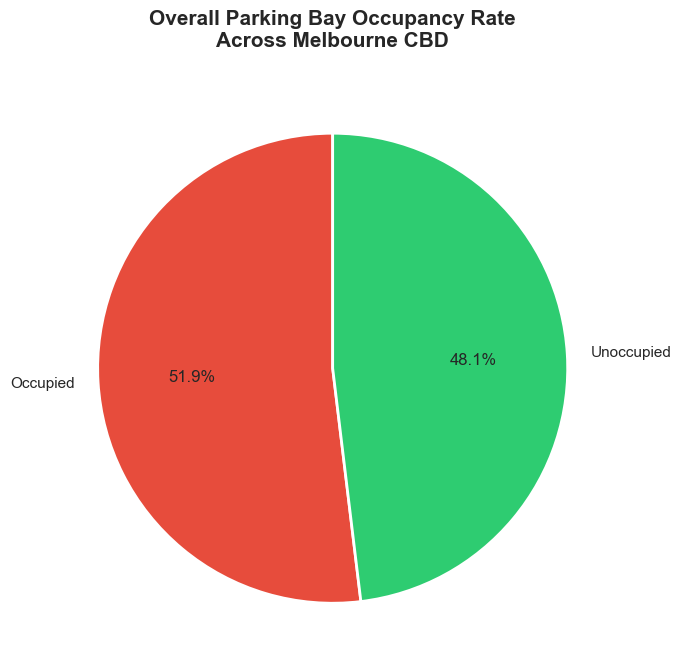

Overall occupancy rate: 51.9%


In [53]:
# KPI 1 — Overall occupancy rate across all bays
occupancy_rate = master['occupied'].mean() * 100
unoccupied_rate = 100 - occupancy_rate

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie([occupancy_rate, unoccupied_rate],
       labels=['Occupied', 'Unoccupied'],
       autopct='%1.1f%%',
       colors=['#e74c3c', '#2ecc71'],
       startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Overall Parking Bay Occupancy Rate\nAcross Melbourne CBD', 
             fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(r"C:\Semester 4\Project\Working\kpi1_occupancy_rate.png", dpi=150)
plt.show()
print(f"Overall occupancy rate: {occupancy_rate:.1f}%")

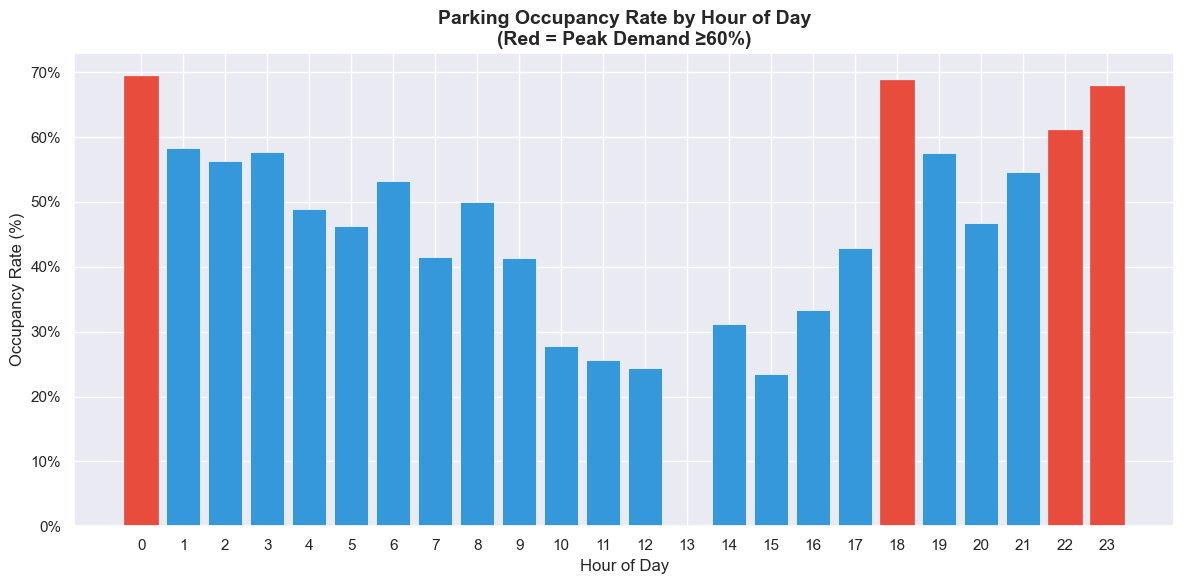

In [55]:
# KPI 2 — Occupancy by hour of day
hourly_occ = master.groupby('hour')['occupied'].mean() * 100

fig, ax = plt.subplots()
bars = ax.bar(hourly_occ.index, hourly_occ.values, color='#3498db', edgecolor='white', linewidth=0.5)

# Highlight peak hours
for i, bar in enumerate(bars):
    if hourly_occ.values[i] >= 60:
        bar.set_color('#e74c3c')

ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Occupancy Rate (%)', fontsize=12)
ax.set_title('Parking Occupancy Rate by Hour of Day\n(Red = Peak Demand ≥60%)', 
             fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig(r"C:\Semester 4\Project\Working\kpi2_occupancy_by_hour.png", dpi=150)
plt.show()

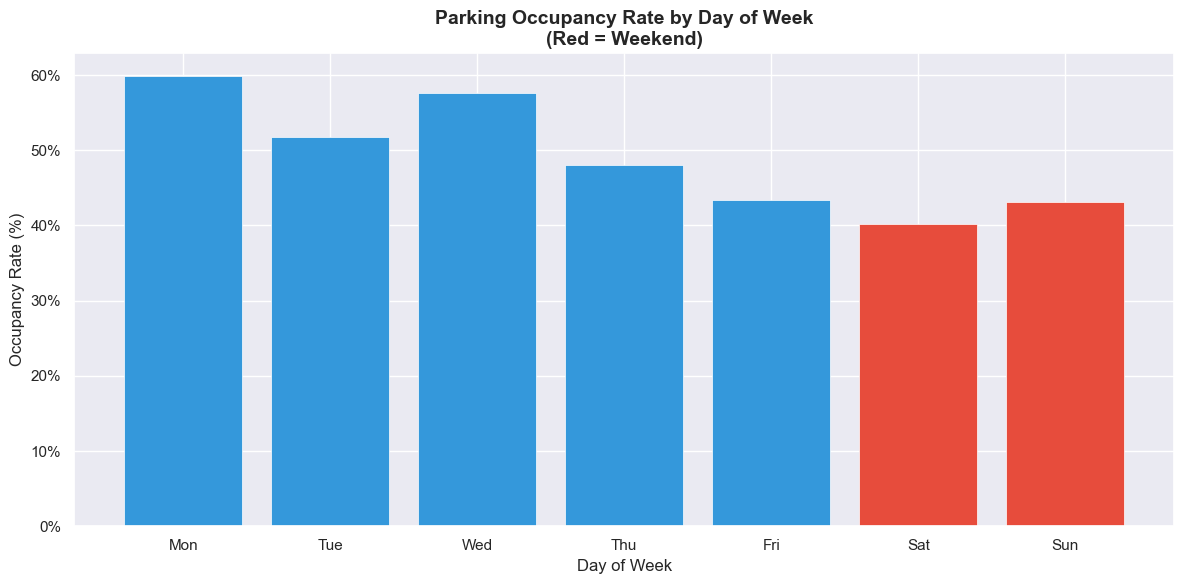

In [57]:
# KPI 3 — Occupancy by day of week
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily_occ = master.groupby('day_of_week')['occupied'].mean() * 100

fig, ax = plt.subplots()
colors = ['#e74c3c' if i >= 5 else '#3498db' for i in range(7)]
ax.bar(day_labels, daily_occ.values, color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Occupancy Rate (%)', fontsize=12)
ax.set_title('Parking Occupancy Rate by Day of Week\n(Red = Weekend)', 
             fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.savefig(r"C:\Semester 4\Project\Working\kpi3_occupancy_by_day.png", dpi=150)
plt.show()

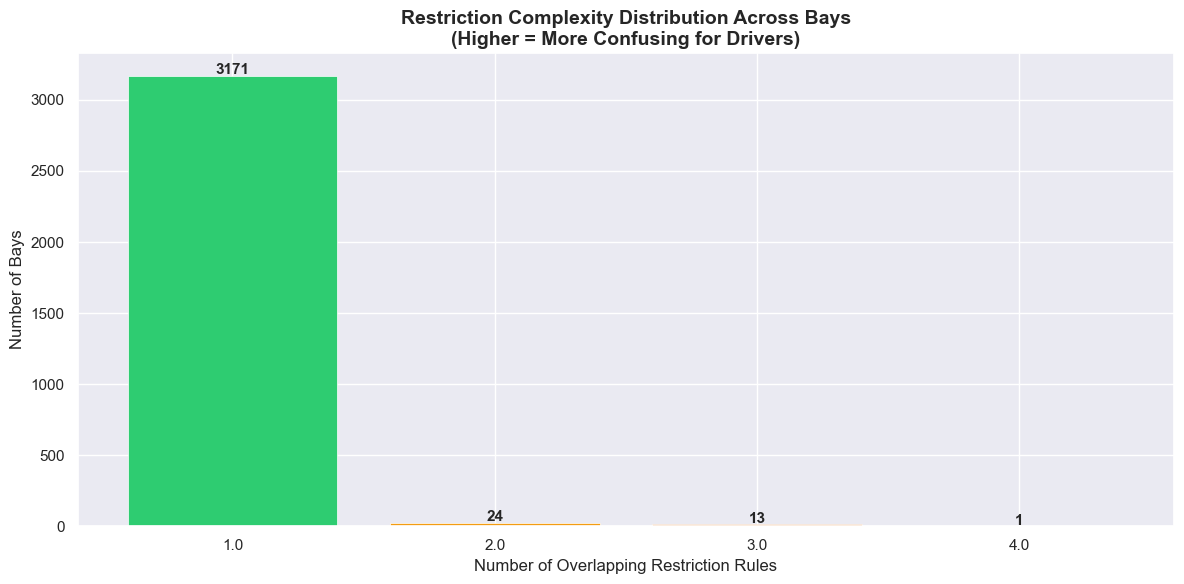

In [59]:
# KPI 4 — Restriction complexity distribution
fig, ax = plt.subplots()
complexity_counts = master['restriction_complexity'].value_counts().sort_index()
bars = ax.bar(complexity_counts.index.astype(str), complexity_counts.values,
              color=['#2ecc71','#f39c12','#e67e22','#e74c3c','#c0392b','#922b21'],
              edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, complexity_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(val), ha='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Number of Overlapping Restriction Rules', fontsize=12)
ax.set_ylabel('Number of Bays', fontsize=12)
ax.set_title('Restriction Complexity Distribution Across Bays\n(Higher = More Confusing for Drivers)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Semester 4\Project\Working\kpi4_restriction_complexity.png", dpi=150)
plt.show()

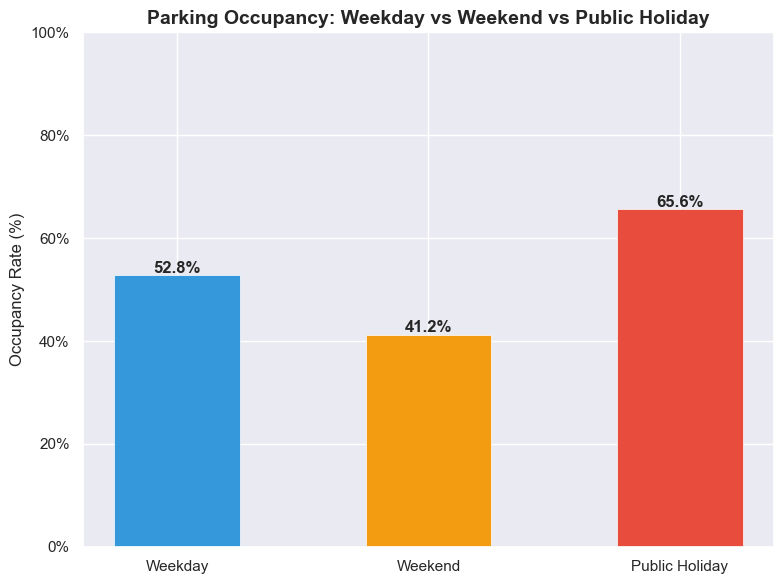

In [61]:
# KPI 5 — Occupancy on public holidays vs normal days vs weekends
comparison = master.groupby(['is_public_holiday','is_weekend'])['occupied'].mean() * 100
labels = ['Weekday', 'Weekend', 'Public Holiday']
values = [
    master[(master['is_public_holiday']==0) & (master['is_weekend']==0)]['occupied'].mean() * 100,
    master[(master['is_public_holiday']==0) & (master['is_weekend']==1)]['occupied'].mean() * 100,
    master[master['is_public_holiday']==1]['occupied'].mean() * 100
]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(labels, values, color=['#3498db','#f39c12','#e74c3c'], 
              edgecolor='white', linewidth=0.5, width=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Occupancy Rate (%)', fontsize=12)
ax.set_title('Parking Occupancy: Weekday vs Weekend vs Public Holiday', 
             fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(r"C:\Semester 4\Project\Working\kpi5_occupancy_by_daytype.png", dpi=150)
plt.show()

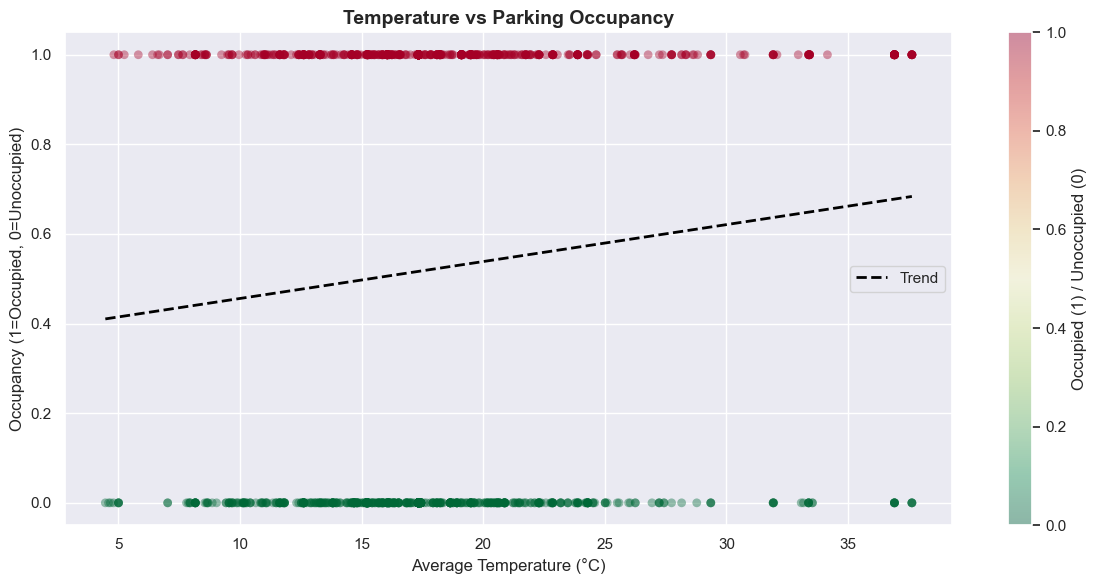

Correlation between temperature and occupancy: 0.066


In [63]:
# KPI 6 — Temperature vs occupancy correlation
fig, ax = plt.subplots()
scatter = ax.scatter(master['avg_temperature'], master['occupied'],
                     alpha=0.4, c=master['occupied'], cmap='RdYlGn_r', 
                     edgecolors='none', s=40)

# Trend line
z = np.polyfit(master['avg_temperature'], master['occupied'], 1)
p = np.poly1d(z)
temp_range = np.linspace(master['avg_temperature'].min(), master['avg_temperature'].max(), 100)
ax.plot(temp_range, p(temp_range), color='black', linewidth=2, linestyle='--', label='Trend')

plt.colorbar(scatter, ax=ax, label='Occupied (1) / Unoccupied (0)')
ax.set_xlabel('Average Temperature (°C)', fontsize=12)
ax.set_ylabel('Occupancy (1=Occupied, 0=Unoccupied)', fontsize=12)
ax.set_title('Temperature vs Parking Occupancy', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(r"C:\Semester 4\Project\Working\kpi6_temperature_vs_occupancy.png", dpi=150)
plt.show()

corr = master['avg_temperature'].corr(master['occupied'])
print(f"Correlation between temperature and occupancy: {corr:.3f}")

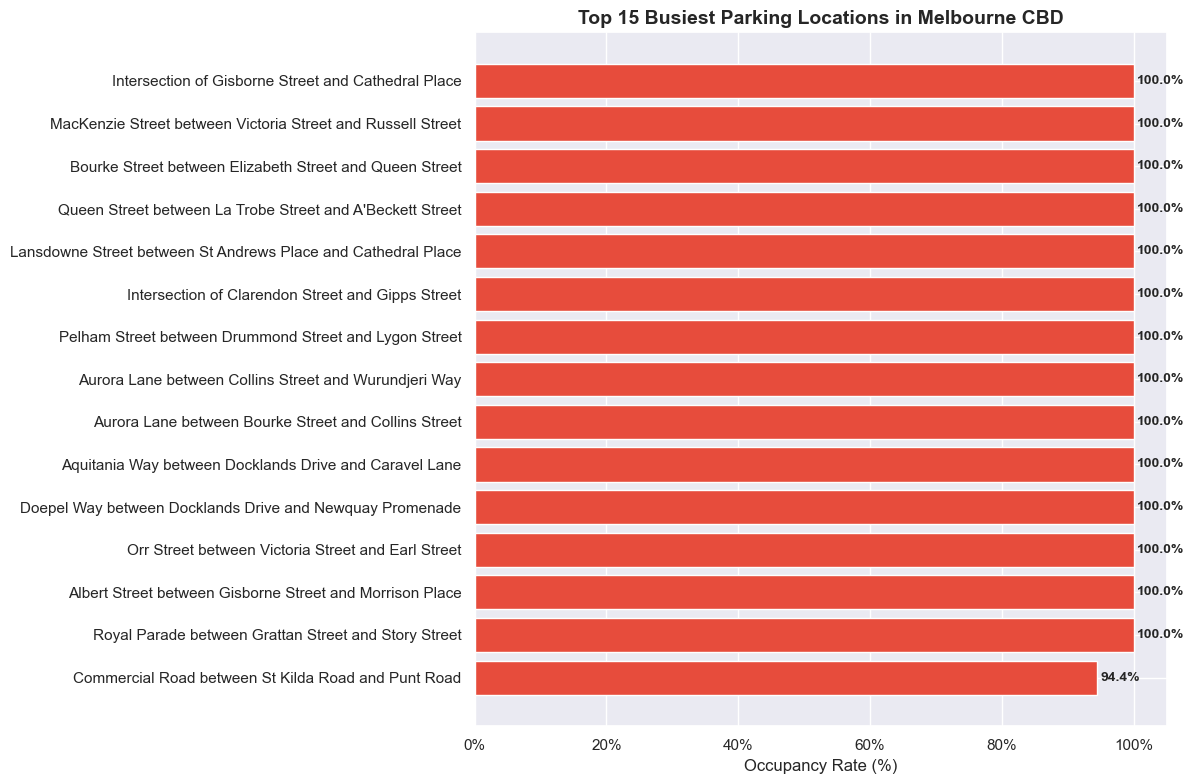

In [65]:
# KPI 7 — Top 15 busiest road segments
top_roads = master.groupby('RoadSegmentDescription')['occupied'].mean().sort_values(ascending=False).head(15) * 100

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top_roads.index, top_roads.values, color='#e74c3c', edgecolor='white')

for bar, val in zip(bars, top_roads.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Occupancy Rate (%)', fontsize=12)
ax.set_title('Top 15 Busiest Parking Locations in Melbourne CBD', 
             fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(r"C:\Semester 4\Project\Working\kpi7_top_busiest_roads.png", dpi=150)
plt.show()

In [71]:
# Only plot bays with real restriction data
real_restrictions = master[master['KerbsideID'].isin(restrictions_clean['BayID'])]
complexity_counts = real_restrictions['restriction_complexity'].value_counts().sort_index()
print(f"Bays with real restriction data: {len(real_restrictions)}")
print(complexity_counts)

Bays with real restriction data: 72
restriction_complexity
1.0    34
2.0    24
3.0    13
4.0     1
Name: count, dtype: int64


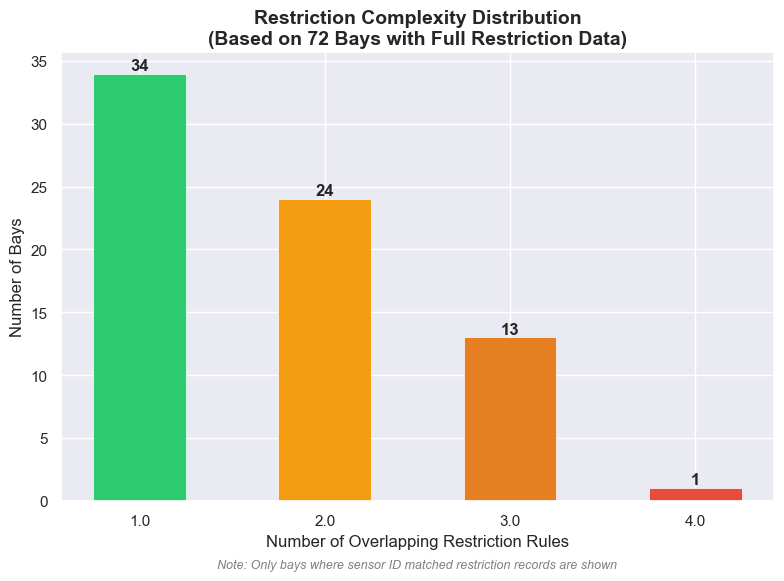

In [73]:
# KPI 4 — Restriction complexity for bays with real data
real_restrictions = master[master['KerbsideID'].isin(restrictions_clean['BayID'])]
complexity_counts = real_restrictions['restriction_complexity'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
bars = ax.bar(complexity_counts.index.astype(str), complexity_counts.values,
              color=colors, edgecolor='white', linewidth=0.5, width=0.5)

for bar, val in zip(bars, complexity_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', fontsize=12, fontweight='bold')

ax.set_xlabel('Number of Overlapping Restriction Rules', fontsize=12)
ax.set_ylabel('Number of Bays', fontsize=12)
ax.set_title('Restriction Complexity Distribution\n(Based on 72 Bays with Full Restriction Data)', 
             fontsize=14, fontweight='bold')
ax.annotate('Note: Only bays where sensor ID matched restriction records are shown',
            xy=(0.5, -0.15), xycoords='axes fraction', ha='center', 
            fontsize=9, color='grey', style='italic')
plt.tight_layout()
plt.savefig(r"C:\Semester 4\Project\Working\kpi4_restriction_complexity.png", dpi=150)
plt.show()